# 04 The time series of a factor

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamadouyamar/CVineMarketGen/blob/main/examples/04_time_series_of_a_factor.ipynb)

<a id="toc"></a>
## Contents

| | |
|---|---|
| **[1. The problem](#s1)** | why twelve independent months are not a year |
| **[2. How it works](#s2)** | a model is a filter, and a filter runs backwards |
| **[3. What you have](#s3)** | one series, one frequency |
| **[4. What is there to model](#s4)** | the tests that say what the filter must remove |
| **[5. The two filters](#s5)** | [5.1 The GARCH family](#s5-1) · [5.2 The hidden Markov model](#s5-2) |
| **[6. Is the model right](#s6)** | [6.1 The bootstrap test](#s6-1) · [6.2 Choosing among 28 candidates](#s6-2) |
| **[7. Paths](#s7)** | the filter run backwards from the last state |
| **[8. The same, daily](#s8)** | what changes at the trader's frequency |
| **[9. The fitted object out](#s9)** | what notebook 05 reads |
| **[10. What comes next](#s10)** | |

---

<a id="s1"></a>
## 1. The problem

You need paths, not single months. A risk number over a horizon, a drawdown,
a funding test, a backtest of a strategy: each of them reads a *sequence* of
returns, and the sequence is where the previous notebooks stop. Notebook 03
produced twenty-five thousand months with no order among them, which is the
right object for a one-month question and the wrong one for a one-year
question.

Three things go wrong if you make a year by drawing twelve of those months
independently.

1. **The bad months come alone.** In the data they arrive in stretches:
   2008, 2020, 2022 are runs of large moves, not isolated ones. Independent
   draws scatter them, so every simulated year gets a little turbulence and
   none gets a crisis.
2. **The horizon risk is wrong in both directions.** Clustering fattens the
   tail of a cumulative return, while the independence assumption thins it;
   at the same time independent draws give every year its own extreme day, so
   a one-day risk measure comes out too severe.
3. **You have nothing to start from.** A path has to begin somewhere, and the
   state the market is actually in, calm or turbulent, is information the
   exchangeable draw threw away.

This notebook takes one factor, finds what its history has that a single
month cannot show, and builds the object that produces paths.

---

<a id="s2"></a>
## 2. How it works: a model is a filter, and a filter runs backwards


<sub>[back to contents](#toc)</sub>

**What this section is for.** The one idea the rest of the notebook rests on.

A model of the dynamics is not used here to forecast. It is used to strip the
predictable part out of the series and to put it back.

$$
r_t \;\longmapsto\; \varepsilon_t \quad\text{(the filter)}, \qquad
\varepsilon_t \;\longmapsto\; r_t \quad\text{(its inverse)} .
$$

Forwards, the model removes what its own past implies, mostly the size of the
moves, and leaves a *generalized error* $\varepsilon_t$ that is independent
and identically distributed over time. Backwards, given i.i.d. errors and the
state at the end of the sample, the same equations rebuild returns one period
at a time, with the clustering and the starting state put back.

That is the whole construction, and it answers the three difficulties: the
errors are exchangeable so they can be drawn the way notebooks 01 to 03 draw
anything, while the returns they produce are not. It is also what makes
notebook 05 possible, where the errors of seven factors are drawn together
from the vine and each factor's own filter turns them back into paths.

**The process.**

1. *What is there to model.* Tests for structure in the level and in the size.
2. *Fit.* Two filters, the GARCH family and the hidden Markov model, and the
   error each leaves behind.
3. *Check and choose.* A parametric-bootstrap goodness-of-fit test on what a
   candidate simulates, then the information criterion among those that pass.
4. *Use.* Paths from the last observed state, monthly and daily, and the
   fitted object saved for notebook 05.

Runtime: about 25 minutes, almost all of it the 2,800 bootstrap refits of
step 3 and the daily selection at the end.

## Import

In [1]:
import os, sys, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")          # arch reports iteration limits on a few (2,2) refits
pd.set_option("display.width", 200)

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "examples" else os.getcwd()
sys.path.insert(0, ROOT)
try:
    import cvinemarketgen
except ImportError:                        # Google Colab
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/mamadouyamar/CVineMarketGen.git"], check=True)
    import cvinemarketgen
print("cvinemarketgen", cvinemarketgen.__version__)

from cvinemarketgen import (load_factor_data, load_daily_returns, iid_tests, GarchFamily, GaussianHMM,
                            select_dynamics, gof_bootstrap, fit_johnson_su, johnson_su_cdf)
from cvinemarketgen.selection import _jsu_on
from scipy import stats
import seaborn as sns
A = lambda m: m * 1200                     # monthly mean -> percent a year
V = lambda v: v * np.sqrt(12) * 100        # monthly vol  -> percent a year

cvinemarketgen 0.3.0


---

<a id="s3"></a>
## 3. What you have


<sub>[back to contents](#toc)</sub>

**What this section is for.** The input: one return series, and nothing else.

One series, at one frequency, long enough to fit a model of its dynamics.
Here Equity DM, the developed-market equity excess return of notebook 03,
monthly since June 2007, and its daily counterpart, the SPY return over the
same period, which the last section uses. Nothing else: this notebook takes
no targets and no views, because a filter is estimated from the series and
from nothing else.

In [2]:
F = load_factor_data(cache=os.path.join(ROOT, "data", "factors_cache.csv")).loc["2007-06":"2026-07"]
y = F["Equity DM"]; n = len(y)
D = load_daily_returns(["SPY"], start="2007-06-01", cache=os.path.join(ROOT, "data", "daily_cache_em.csv"))["SPY"]
print(f"monthly Equity DM: {n} months, {y.index.min()} to {y.index.max()}, mean {A(y.mean()):.1f}% a year, vol {V(y.std()):.1f}% a year")
print(f"daily SPY: {len(D)} days, {D.index.min().date()} to {D.index.max().date()}, vol {D.std() * np.sqrt(252) * 100:.1f}% a year")
y.head(3).round(4).to_frame("Equity DM, monthly return").T

factor data read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/factors_cache.csv: 244 months, 2006-04 to 2026-07
daily returns read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/daily_cache_em.csv: 4858 days, 2007-06-04 to 2026-09-24
monthly Equity DM: 230 months, 2007-06 to 2026-07, mean 7.6% a year, vol 16.1% a year
daily SPY: 4858 days, 2007-06-04 to 2026-09-24, vol 19.7% a year


month,2007-06,2007-07,2007-08
"Equity DM, monthly return",-0.0079,-0.0237,-0.0114


The series and its squares. The second panel is the one to look at: the large
months are next to each other.

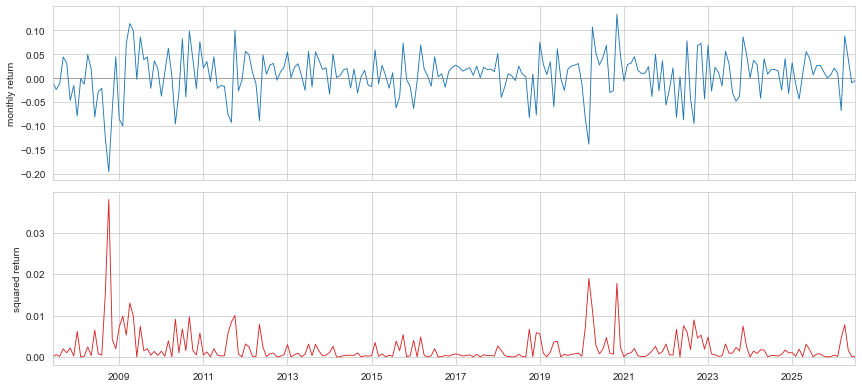

In [3]:
with sns.axes_style("whitegrid"):
    fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True)
    y.plot(ax=axes[0], lw=0.9, color="tab:blue"); axes[0].axhline(0, color="grey", lw=0.6); axes[0].set_ylabel("monthly return")
    (y ** 2).plot(ax=axes[1], lw=0.9, color="tab:red"); axes[1].set_ylabel("squared return"); axes[1].set_xlabel("")
    plt.tight_layout(); plt.show()

---

<a id="s4"></a>
## 4. What is there to model?


<sub>[back to contents](#toc)</sub>

**What this section is for.** Find out what the filter has to remove, before choosing one.

Two questions, each a test, and the answers decide what the filter has to
remove.

*Is the level predictable from its past?* The autocorrelation of the returns,
$\hat\rho_j = \sum_t (r_t - \bar r)(r_{t-j} - \bar r) / \sum_t (r_t - \bar r)^2$,
summarized over $m = 20$ lags by the Ljung-Box statistic

$$
Q_m = n(n+2) \sum_{j=1}^{m} \frac{\hat\rho_j^2}{n - j}, \qquad Q_m \sim \chi^2_m \text{ under independence}.
$$

*Is the size predictable?* The same statistic on $r_t^2$, and Engle's ARCH-LM
test, the $nR^2$ of the regression of $r_t^2$ on its $m$ lags, also
$\chi^2_m$. The three $p$-values first.

In [4]:
pd.Series(iid_tests(y.values)).round(4).rename({"lb_z": "Ljung-Box p, returns", "lb_z2": "Ljung-Box p, squared returns", "arch_lm": "ARCH-LM p"}).to_frame("Equity DM, monthly").T

,"Ljung-Box p, returns","Ljung-Box p, squared returns",ARCH-LM p
"Equity DM, monthly",0.4764,0.0001,0.001


And the same thing as a picture: the two autocorrelation functions with the
band $\pm 1.96/\sqrt n$ a series of independent draws would stay inside.

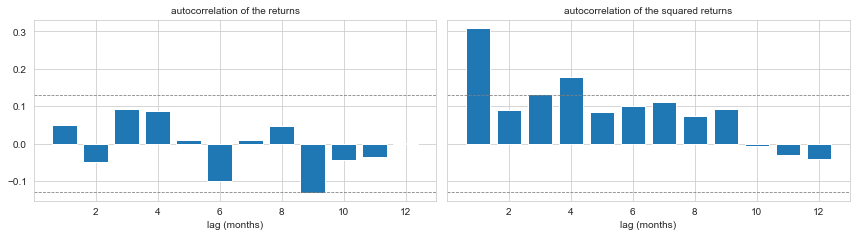

In [5]:
K = 12; acf = lambda s: [s.autocorr(k) for k in range(1, K + 1)]
with sns.axes_style("whitegrid"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), sharey=True)
    for ax, s, lab in [(axes[0], y, "returns"), (axes[1], y ** 2, "squared returns")]:
        ax.bar(range(1, K + 1), acf(s), color="tab:blue")
        ax.axhline(1.96 / np.sqrt(n), color="grey", ls="--", lw=0.8); ax.axhline(-1.96 / np.sqrt(n), color="grey", ls="--", lw=0.8)
        ax.set_title(f"autocorrelation of the {lab}", fontsize=10); ax.set_xlabel("lag (months)")
    plt.tight_layout(); plt.show()

**What the tests say.** Nothing to predict in the level: the Ljung-Box
$p$-value on the returns is 0.48, and the bars in the left panel stay inside
the band. Everything to predict in the size: 0.0001 on the squares and 0.001
for ARCH-LM, and the right panel is outside the band for the first four lags.

So the filter has one job. It has to take the size out, and it can leave the
level alone.

---

<a id="s5"></a>
## 5. The two filters


<sub>[back to contents](#toc)</sub>

**What this section is for.** Fit a model, and look at what it leaves behind.

<a id="s5-1"></a>
### 5.1 The GARCH family

The model writes the return as a constant mean plus an innovation whose
variance depends on the past,

$$
r_t = a + \sigma_t\, \varepsilon_t, \qquad \sigma_t^2 = \omega + \alpha\, e_{t-1}^2 + \beta\, \sigma_{t-1}^2, \qquad e_t = r_t - a,
$$

the GARCH(1,1) of Bollerslev: a large move today raises tomorrow's variance
through $\alpha$, and the variance decays at the rate $\beta$, with an
unconditional level $\omega / (1 - \alpha - \beta)$ and a persistence
$\alpha + \beta$. Variants in the same family: an AR(1) mean $a + b\,r_{t-1}$;
the GJR term $\gamma\, e_{t-1}^2\, \mathbf 1\{e_{t-1} < 0\}$ that lets a fall
raise the variance more than a rise; the EGARCH, the same on the log of the
variance. Estimated by maximum likelihood with a Gaussian innovation, on
returns times 100, the log-likelihood put back on the data's scale so that
the comparisons of step 3 are like for like.

In [6]:
g = GarchFamily("const", "garch", 1, 1).fit(y)
prm = {k: float(np.ravel(v)[0]) for k, v in g.params.items()}
print(f"{g.name}: persistence alpha + beta = {prm['alpha'] + prm['beta']:.3f}, unconditional vol {V(np.sqrt(prm['omega'] / (1 - prm['alpha'] - prm['beta'])) / 100):.1f}% a year")
pd.Series({k: round(prm[k], 4) for k in ("a", "omega", "alpha", "beta")}).to_frame("GARCH(1,1), returns in percent").T

Const-GARCH(1,1): persistence alpha + beta = 0.804, unconditional vol 16.3% a year


,a,omega,alpha,beta
"GARCH(1,1), returns in percent",0.8752,4.3448,0.2802,0.5237


What the model is for is what it leaves behind. With the parameters fitted,
the variance path $\sigma_t^2$ is computed from the data and

$$
\varepsilon_t = \frac{r_t - a}{\sigma_t}
$$

is the *generalized error*: the return with its predictable part, here the
size, taken out. The filter is invertible, since $\varepsilon_t$ and the
state $(e_{t-1}, \sigma_{t-1}^2)$ give $r_t$ back exactly. The fitted
volatility, and the error beside it.

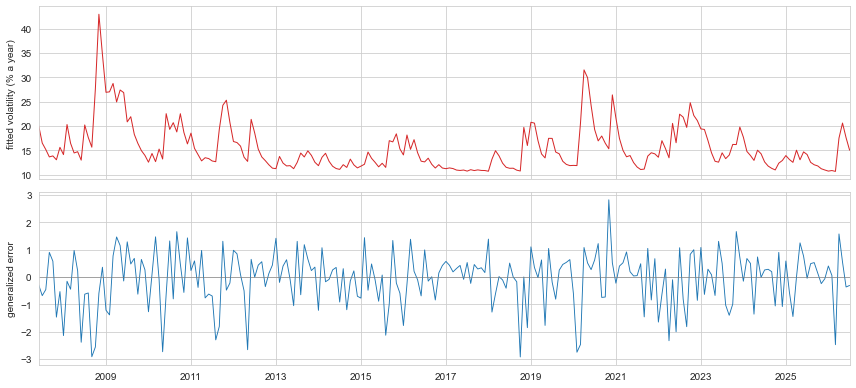

In [7]:
eps = g.filter()
sig = (y - prm["a"] / 100) / eps                                # sigma_t implied by the filter, in the data's units
with sns.axes_style("whitegrid"):
    fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True)
    (sig * np.sqrt(12) * 100).plot(ax=axes[0], color="tab:red", lw=1); axes[0].set_ylabel("fitted volatility (% a year)")
    eps.plot(ax=axes[1], color="tab:blue", lw=0.9); axes[1].axhline(0, color="grey", lw=0.6); axes[1].set_ylabel("generalized error"); axes[1].set_xlabel("")
    plt.tight_layout(); plt.show()

The test of step 1, run again on the error: what was in the squares should be
gone.

In [8]:
pd.DataFrame({"returns": iid_tests(y.values), "generalized error of GARCH(1,1)": iid_tests(eps.values)}).round(4).rename(index={"lb_z": "Ljung-Box p", "lb_z2": "Ljung-Box p, squares", "arch_lm": "ARCH-LM p"})

,returns,"generalized error of GARCH(1,1)"
Ljung-Box p,0.4764,0.8717
"Ljung-Box p, squares",0.0001,0.5256
ARCH-LM p,0.0010,0.5992


**What the fit says.** Persistence 0.80, which puts the half-life of a shock
at about three months, and an unconditional volatility of 16.3 percent a year
against 16.1 in the sample. The fitted volatility runs from 10 percent in the
calm stretches to above 40 in late 2008.

The error is what matters. Its three $p$-values are 0.87, 0.53 and 0.60,
against 0.48, 0.0001 and 0.001 for the returns. What was in the squares is
gone. The filter did its one job.

<a id="s5-2"></a>
### 5.2 The hidden Markov model

The second model says the return comes from one of $K$ regimes,
$r_t \mid s_t = k \sim N(\mu_k, \sigma_k^2)$, with $s_t$ a Markov chain of
transition matrix $Q$: a calm state and a turbulent one, each persistent.
Estimated by the EM algorithm (GenHMM1d). The state is never observed; what
the data give is its filtered probability
$\eta_{t|t-1,k} = \Pr(s_t = k \mid r_1, \dots, r_{t-1})$, updated by Bayes'
rule at each observation, so that the predictive distribution of the next
return is the mixture

$$
F_t(r) = \sum_{k=1}^{K} \eta_{t|t-1,k}\, \Phi\!\left( \frac{r - \mu_k}{\sigma_k} \right).
$$

In [9]:
hm = {K: GaussianHMM(K).fit(y) for K in (2, 3)}
pd.DataFrame({f"HMM({K})": {"regime means (%/yr)": np.round(A(h.mu), 1), "regime vols (%/yr)": np.round(V(h.sigma), 1),
                            "stay probabilities": np.round(np.diag(h.Q), 3), "expected durations (months)": np.round(1 / (1 - np.diag(h.Q)), 1)}
              for K, h in hm.items()}).T

,regime means (%/yr),regime vols (%/yr),stay probabilities,expected durations (months)
HMM(2),"[-0.4, 15.8]","[20.9, 8.4]","[0.907, 0.905]","[10.8, 10.5]"
HMM(3),"[-57.1, 15.2, 92.6]","[16.0, 9.0, 8.0]","[0.593, 0.903, 0.156]","[2.5, 10.3, 1.2]"


Its generalized error is a different object from the GARCH's: the Rosenblatt
transform, the predictive distribution evaluated at the realized return and
mapped to a normal score,

$$
v_t = F_t(r_t), \qquad \varepsilon_t = \Phi^{-1}(v_t),
$$

i.i.d. uniform and i.i.d. normal under the model, and invertible in the same
way: given $\varepsilon_t$ and the probabilities,
$r_t = F_t^{-1}(\Phi(\varepsilon_t))$ by bisection on the mixture, and the
probabilities are updated. Two models, two different errors, one standardized
residual and one probability transform, with the same two properties: i.i.d.
by construction, and a recursion that gives the return back.

The filtered probability of the turbulent regime over the sample, which is
the state a path would start from.

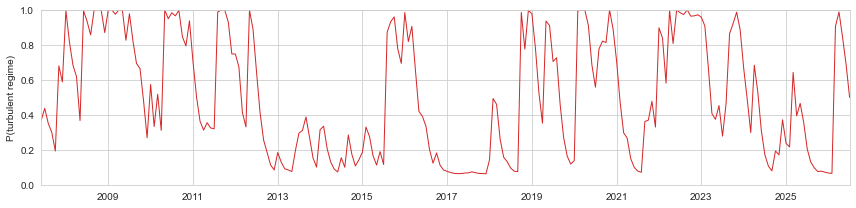

In [10]:
h2 = hm[2]; turb = int(np.argmax(h2.sigma))
with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(12, 3))
    pd.Series(np.asarray(h2.regimes, float)[:, turb], index=y.index).plot(ax=ax, color="tab:red", lw=1)
    ax.set_ylabel("P(turbulent regime)"); ax.set_ylim(0, 1); ax.set_xlabel(""); plt.tight_layout(); plt.show()

And the same three tests on what the two hidden Markov models leave behind.

In [11]:
pd.DataFrame({f"HMM({K})": iid_tests(h.filter().values) for K, h in hm.items()}).round(4).rename(index={"lb_z": "Ljung-Box p", "lb_z2": "Ljung-Box p, squares", "arch_lm": "ARCH-LM p"})

,HMM(2),HMM(3)
Ljung-Box p,0.7149,0.6249
"Ljung-Box p, squares",0.5785,0.0559
ARCH-LM p,0.5596,0.0283


**What the fit says.** Two regimes: one at $-0.4$ percent a year with a
volatility of 21, one at 16 percent a year with a volatility of 8. Both last
about ten months. That is a crisis state and a normal state, and the picture
shows the chain sitting in the first one through 2008, 2020 and 2022.

Three regimes fit something else. The middle state is the normal one, but the
other two last 2.5 and 1.2 months and have means of $-57$ and $+93$ percent a
year. Those are not volatility states, they are outlier catchers: with twelve
parameters on 230 months, the likelihood is maximised by putting a state on a
handful of extreme months.

That shows up in the error. The Rosenblatt transform divides out the model's
predictive variance, so a variance that spikes for one month and reverts does
not track the long turbulent stretches of 2008, 2020 and 2022, and they stay
in the error: ARCH-LM gives 0.028, a rejection at 5 percent, and the squares
0.056, on the line. The two-regime error is clear on all three, 0.71, 0.58
and 0.56.

---

<a id="s6"></a>
## 6. Is the model right?


<sub>[back to contents](#toc)</sub>

**What this section is for.** Test what a candidate simulates, then choose among those that pass.

<a id="s6-1"></a>
### 6.1 The parametric-bootstrap goodness-of-fit test

Passing the diagnostics says the error carries no predictable structure. It
does not say the model's distribution is right, and the distribution is what
a path is made of. The test is the one of the master's thesis (Thioub, 2019;
GenHMM1d's `GofHMMGen`). Under the fitted model the uniforms of the
generalized error, $v_t = G(\varepsilon_t)$ with $G$ the error's
distribution, are i.i.d. uniform on $[0,1]$, and the Cramér-von Mises
statistic measures their distance from uniformity,

$$
W^2 = \frac{1}{12 n} + \sum_{t=1}^{n} \left( v_{(t)} - \frac{2t - 1}{2n} \right)^2,
$$

with $v_{(t)}$ the sorted uniforms. Its distribution once the parameters are
estimated is not known in closed form, so it is bootstrapped: $B$ series of
length $n$ are simulated from the fitted model, the model is refitted on each,
the statistic is recomputed, and the $p$-value is the share of bootstrap
statistics above the observed one.

**What $G$ is decides what is tested.** For the hidden Markov model, $v_t$ is
the Rosenblatt transform above, uniform by construction, and the bootstrap
simulates the chain and refits it by EM: the thesis's test exactly. For the
GARCH family the generator does not simulate a Gaussian error; it draws the
error from a Johnson SU fitted to the residual's skewness and kurtosis, the
marginal of notebook 02. So $G$ is that Johnson SU, the bootstrap simulates
the GARCH recursion with Johnson SU errors and refits both the model and the
marginal on each series, and what is tested is the pair that will actually be
simulated, the filter together with its error's shape.

The cell runs the test three times on the same data: the GARCH with the error
it will use, the same GARCH forced to a Gaussian error, and the two-regime
hidden Markov model. $B = 100$.

In [12]:
t0 = time.time()
gof_g = gof_bootstrap(g, y, B=100, seed=0)
gof_g_norm = gof_bootstrap(g, y, B=100, seed=0, innovation="gaussian")
gof_h2 = gof_bootstrap(h2, y, B=100, seed=0)
print(f"three bootstrap tests, 300 refits, in {time.time() - t0:.0f} s")
pd.DataFrame({"GARCH(1,1), Johnson SU error": {"Cramer-von Mises statistic": gof_g["stat"], "bootstrap p-value": gof_g["pvalue"]},
              "GARCH(1,1), Gaussian error": {"Cramer-von Mises statistic": gof_g_norm["stat"], "bootstrap p-value": gof_g_norm["pvalue"]},
              "HMM(2), Rosenblatt uniforms": {"Cramer-von Mises statistic": gof_h2["stat"], "bootstrap p-value": gof_h2["pvalue"]}}).T.round(3)

three bootstrap tests, 300 refits, in 146 s


,Cramer-von Mises statistic,bootstrap p-value
"GARCH(1,1), Johnson SU error",0.081,0.16
"GARCH(1,1), Gaussian error",0.210,0.00
"HMM(2), Rosenblatt uniforms",0.055,0.33


The same three, as the histograms the statistic measures: a model that fits
gives a flat one.

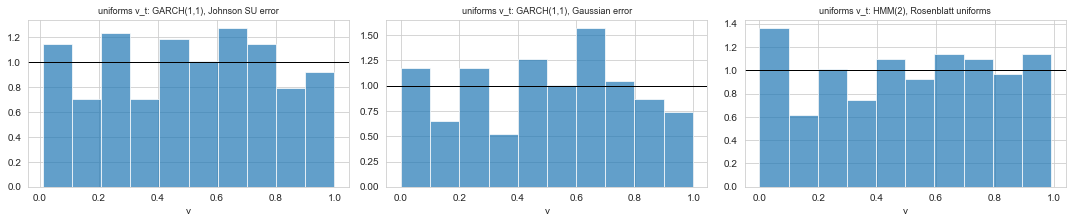

In [13]:
with sns.axes_style("whitegrid"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.2))
    e_g = g.filter().values
    for ax, u, lab in [(axes[0], johnson_su_cdf(_jsu_on(e_g), e_g), "GARCH(1,1), Johnson SU error"),
                       (axes[1], stats.norm.cdf(e_g), "GARCH(1,1), Gaussian error"),
                       (axes[2], stats.norm.cdf(h2.filter().values), "HMM(2), Rosenblatt uniforms")]:
        ax.hist(u, bins=10, density=True, color="tab:blue", alpha=0.7); ax.axhline(1, color="black", lw=1)
        ax.set_title(f"uniforms v_t: {lab}", fontsize=9); ax.set_xlabel("v")
    plt.tight_layout(); plt.show()

**What the test says.** Two of the three pass. The GARCH with the error it
will actually simulate has a $p$-value of 0.16: its uniforms are as far from
flat as 16 percent of the series the fitted model generates itself. The
two-regime hidden Markov model passes at 0.33.

The same GARCH with a Gaussian error is rejected outright, $p = 0.00$. The
middle histogram shows why: too much mass in the lowest bin, too little in
the highest, which is a skewness of $-0.67$ that no normal can carry. The
filter is right and the error's distribution is wrong, and that is enough to
reject the pair.

One caveat carries into the next step. The statistic looks at the
*distribution* of the uniforms, not at their order in time. A model whose
error is still clustered can pass it if the marginal is right. That is why
the table below keeps the three diagnostics next to the test.

<a id="s6-2"></a>
### 6.2 Choosing among the candidates

The candidate set is a grid: the mean is a constant or an AR(1), the variance
is constant or a GARCH, GJR or EGARCH of orders up to (2, 2), and beside them
the hidden Markov model with two or three regimes. That is what
`select_dynamics` searches, and it is worth seeing rather than counting.

In [14]:
grid = pd.DataFrame(index=["const", "ar1"], columns=["const", "garch(p,q)", "gjr(p,q)", "egarch(p,q)"])
grid.loc[:, :] = "(1,1) (1,2) (2,1) (2,2)"; grid["const"] = "-"
grid.index.name = "mean \\ variance"
print("the GARCH family grid, plus HMM(2) and HMM(3):", 2 * (1 + 3 * 4) + 2, "candidates")
grid

the GARCH family grid, plus HMM(2) and HMM(3): 28 candidates


,const,"garch(p,q)","gjr(p,q)","egarch(p,q)"
mean \ variance,,,,
const,-,"(1,1) (1,2) (2,1) (2,2)","(1,1) (1,2) (2,1) (2,2)","(1,1) (1,2) (2,1) (2,2)"
ar1,-,"(1,1) (1,2) (2,1) (2,2)","(1,1) (1,2) (2,1) (2,2)","(1,1) (1,2) (2,1) (2,2)"


The rule has two steps, in this order.

1. **Goodness of fit.** The bootstrap test above on every candidate, with
   $B = 100$. A candidate is admissible if its $p$-value is at least 5
   percent, since a model whose simulated series do not look like the data
   has not done its job, however high its likelihood.
2. **Parsimony among the admissible.** The lowest Bayesian information
   criterion,
   $$\mathrm{BIC} = -2\,\ell + k \ln n,$$
   with $\ell$ the log-likelihood on the data's scale and $k$ the number of
   parameters, which charges each parameter $\ln n \approx 5.4$ units of
   log-likelihood.

The order matters and it is not the usual one: the likelihood never gets to
choose among models that the data reject. This is the rule of the master's
thesis, and `select_dynamics(criterion='gof')` is it. It costs 2,800 refits,
about twelve minutes here.

In [15]:
t0 = time.time()
sel = select_dynamics(y.to_frame(), B=100, seed=0, verbose=False)
best = sel.models["Equity DM"]
cand = sel.candidates.sort_values("bic")[["model", "n_params", "bic", "gof_pvalue", "passed", "lb_z", "lb_z2", "arch_lm"]].reset_index(drop=True)
print(f"{len(cand)} candidates fitted and tested in {time.time() - t0:.0f} s | selected {best.name} | passing the test: {int(cand['passed'].sum())}")
cand.round(3)

/Users/mamadouthioub/opt/anaconda3/lib/python3.8/site-packages/arch/univariate/base.py:753: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
/Users/mamadouthioub/opt/anaconda3/lib/python3.8/site-packages/arch/univariate/base.py:753: ConvergenceWarning: The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
/Users/mamadouthioub/opt/anaconda3/lib/python3.8/site-packages/arch/univariate/base.py:753: ConvergenceWarning: The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
/Users/mamadouthioub/opt/anaconda3/lib/python3.8/site-packages/arch/univariate/base.py:753: ConvergenceWarning: The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.

  warning

28 candidates fitted and tested in 477 s | selected Const-GJR(1,1) | passing the test: 27


,model,n_params,bic,gof_pvalue,passed,lb_z,lb_z2,arch_lm
0,"Const-GJR(1,1)",5,-786.001,0.42,True,0.816,0.466,0.522
1,"Const-GJR(1,2)",6,-781.456,0.34,True,0.807,0.601,0.589
2,"Const-GJR(2,1)",6,-780.562,0.41,True,0.816,0.466,0.522
3,"AR(1)-GJR(1,1)",6,-776.455,0.33,True,0.821,0.438,0.508
4,"Const-GJR(2,2)",7,-776.018,0.33,True,0.807,0.600,0.589
5,"AR(1)-GJR(1,2)",7,-771.997,0.29,True,0.811,0.581,0.571
6,"Const-GARCH(1,1)",4,-771.471,0.16,True,0.872,0.526,0.599
7,"AR(1)-GJR(2,1)",7,-771.021,0.31,True,0.821,0.438,0.508
8,"Const-EGARCH(1,1)",4,-770.445,0.23,True,0.793,0.753,0.702
9,"AR(1)-GJR(2,2)",8,-766.563,0.27,True,0.811,0.581,0.571


**What the table says.** Twenty-seven of the twenty-eight pass. The only
rejection is the three-regime hidden Markov model at 0.04, the model that
fitted a 1.2-month regime, and it fails the diagnostics on the squares too.

The two constant-variance models pass the test at 0.30 and 0.18 while their
squared errors are autocorrelated at $p = 0.000$. That is the caveat of the
previous step in one line: the Johnson SU absorbs their kurtosis, so their
uniforms look flat, and only the diagnostics see that the ordering is wrong.
The BIC puts them last anyway, 38 units behind.

The winner is the GJR(1,1) with a constant mean. It beats the plain GARCH by
14.5 units of BIC for one extra parameter, which costs 5.4, so the asymmetry
term earns its place: $\alpha$ is zero and $\gamma$ is 0.45, meaning only
falls raise next month's variance. The two-regime hidden Markov model is
eleventh, 20 units behind, and passes everything, so the next step keeps it
as the alternative description.

---

<a id="s7"></a>
## 7. Paths: the filter run backwards


<sub>[back to contents](#toc)</sub>

**What this section is for.** Turn i.i.d. errors back into returns, starting from where the market is.

The filter took returns to i.i.d. errors; its inverse takes i.i.d. errors to
returns, starting from the state at the end of the sample. For the GARCH the
state is $(e_T, \sigma_T^2)$ and the recursion is

$$
\sigma_{T+h}^2 = \omega + \alpha\, e_{T+h-1}^2 + \beta\, \sigma_{T+h-1}^2, \qquad
r_{T+h} = a + \sigma_{T+h}\, \varepsilon_{T+h}, \qquad h = 1, 2, \dots
$$

For the hidden Markov model the state is the filtered probability
$\eta_{T|T}$, and each step draws
$r_{T+h} = F_{T+h}^{-1}(\Phi(\varepsilon_{T+h}))$ and then updates it.

The errors of a path are not normal draws. They come from a Johnson SU fitted
to the generalized error's own skewness and kurtosis, the marginal of
notebook 02, so that the shape of the error survives the inversion; in
notebook 05 the errors of several factors are drawn together from the vine
instead. The cell draws 2,000 paths of 24 months from the selected model, the
same from the two-regime hidden Markov model, and the same number of
independent draws in the manner of notebook 01.

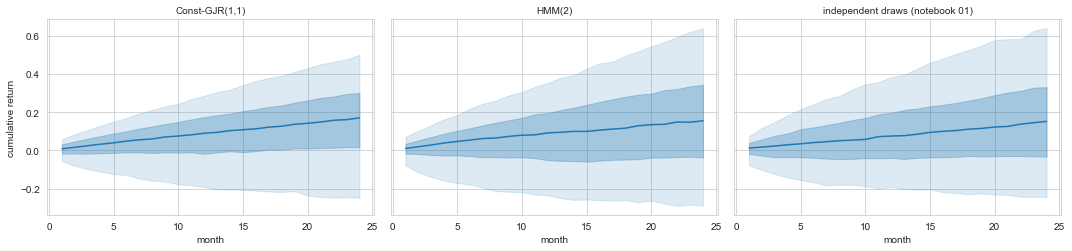

In [16]:
H, NP = 24, 2000
def jsu_draws(eps_hist, n_paths, horizon, seed):
    p = fit_johnson_su(float(eps_hist.skew()), max(float(eps_hist.kurt() + 3), 3.1 + 2 * float(eps_hist.skew()) ** 2))
    zz = np.random.default_rng(seed).standard_normal((n_paths, horizon))
    e = p["xi"] + p["lambda"] * np.sinh((zz - p["gamma"]) / p["delta"]); return (e - e.mean()) / e.std()
paths = {best.name: best.unfilter(jsu_draws(best.filter(), NP, H, 1)),
         "HMM(2)": h2.unfilter(jsu_draws(h2.filter(), NP, H, 1)),
         "independent draws (notebook 01)": y.mean() + y.std() * jsu_draws((y - y.mean()) / y.std(), NP, H, 2)}
with sns.axes_style("whitegrid"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), sharey=True)
    for ax, (k, P) in zip(axes, paths.items()):
        cum = np.cumprod(1 + P, axis=1) - 1; q = np.quantile(cum, [0.05, 0.25, 0.5, 0.75, 0.95], axis=0)
        ax.fill_between(range(1, H + 1), q[0], q[4], alpha=0.15, color="tab:blue"); ax.fill_between(range(1, H + 1), q[1], q[3], alpha=0.3, color="tab:blue")
        ax.plot(range(1, H + 1), q[2], color="tab:blue"); ax.set_title(k, fontsize=10); ax.set_xlabel("month")
    axes[0].set_ylabel("cumulative return"); plt.tight_layout(); plt.show()

Three things to compare with the history: how far the two-year return
spreads, how fat the monthly returns are, and whether the size of a move
still predicts the next one along a path.

In [17]:
def stats_of(P):
    cum = np.prod(1 + P, axis=1) - 1; sq = P ** 2
    return {"24-month cumulative return: vol (%)": cum.std() * 100, "24-month cumulative return: 5% quantile (%)": np.quantile(cum, 0.05) * 100,
            "monthly returns: pooled kurtosis": stats.kurtosis(P.ravel()) + 3,
            "autocorrelation of squared returns, lag 1": np.mean([np.corrcoef(sq[i, :-1], sq[i, 1:])[0, 1] for i in range(P.shape[0])])}
hist_roll = (1 + y).rolling(H).apply(np.prod, raw=True).dropna() - 1
rows = {"history (rolling 24-month windows)": {"24-month cumulative return: vol (%)": hist_roll.std() * 100, "24-month cumulative return: 5% quantile (%)": hist_roll.quantile(0.05) * 100,
                                               "monthly returns: pooled kurtosis": y.kurt() + 3, "autocorrelation of squared returns, lag 1": (y ** 2).autocorr(1)}}
rows.update({k: stats_of(P) for k, P in paths.items()})
pd.DataFrame(rows).T.round(2)

,24-month cumulative return: vol (%),24-month cumulative return: 5% quantile (%),monthly returns: pooled kurtosis,"autocorrelation of squared returns, lag 1"
history (rolling 24-month windows),21.56,-19.12,4.55,0.31
"Const-GJR(1,1)",23.17,-24.85,18.88,0.07
HMM(2),27.84,-28.93,5.42,0.03
independent draws (notebook 01),27.09,-24.31,4.68,-0.04


One column of that table needs a second look, and it is the kurtosis. A GARCH
recursion has a finite fourth moment only if

$$
\mathbb{E}\big[(\alpha\,\varepsilon^2 + \gamma\,\varepsilon^2\,\mathbf 1\{\varepsilon<0\} + \beta)^2\big] < 1 ,
$$

and nothing in the fit or in the selection enforces it: the likelihood is
finite either way and the goodness-of-fit test looks at 230 standardized
errors, which say nothing about a moment of the process. The cell computes
the condition for the selected model and counts how far the paths run.

In [18]:
P = best.params; al, be, ga = P["alpha"][0], P["beta"][0], P["gamma"]
k_eps = float(best.filter().kurt() + 3)
E4 = (al ** 2 + al * ga + ga ** 2 / 2) * k_eps + 2 * (al + ga / 2) * be + be ** 2
Pb = paths[best.name]; kp = stats.kurtosis(Pb, axis=1) + 3
pd.Series({"alpha + gamma/2 + beta (persistence)": al + ga / 2 + be, "fourth-moment condition (below 1 for a finite kurtosis)": E4,
           "pooled kurtosis of the paths": stats.kurtosis(Pb.ravel()) + 3, "median kurtosis of a path": float(np.median(kp)),
           "95th percentile of a path's kurtosis": float(np.quantile(kp, 0.95)),
           "share of paths with a month beyond the worst in the sample": float(np.mean(np.abs(Pb).max(axis=1) > np.abs(y).max())),
           "largest simulated month (%)": float(np.abs(Pb).max() * 100), "worst month in the sample (%)": float(np.abs(y).max() * 100)}).round(3).to_frame(best.name)

,"Const-GJR(1,1)"
alpha + gamma/2 + beta (persistence),0.846
fourth-moment condition (below 1 for a finite kurtosis),1.021
pooled kurtosis of the paths,18.877
median kurtosis of a path,2.831
95th percentile of a path's kurtosis,5.257
share of paths with a month beyond the worst in the sample,0.059
largest simulated month (%),89.293
worst month in the sample (%),19.510


**What the paths say.** The two-year volatility is 23 percent for the GJR
against 22 in the history, 28 for the hidden Markov model and 27 for
independent draws. The GJR is closest because it starts from the calm
variance of mid-2026, which holds its first months down. The hidden Markov
model is wide for a different reason: its two regimes are 16 percentage
points apart in mean, so a path that stays in one of them for two years ends
far from a path that stays in the other.

The autocorrelation of the squares is 0.07 and 0.03 along the paths against
0.31 in the history. Both are too low, and the history's 0.31 is one episode,
2008 to 2009, measured over 230 months; the path figure is measured over 24.

**The kurtosis column is a warning, not a result.** The GJR paths pool to 19
against 4.6 in the history, but the median path has a kurtosis of 2.8 and the
95th percentile 5.3. The pooled figure comes from a few explosive paths: 6
percent of them contain a month worse than the worst in the sample, and the
largest simulated month is 89 percent.

The second table says why. The fourth-moment condition of this model is 1.02,
just above one, so its unconditional kurtosis is infinite and any pooled
estimate grows with the number of paths. The persistence of 0.85 is not the
problem; the size of $\gamma$ is. Neither the likelihood nor the
goodness-of-fit test can see this, because both look at 230 standardized
errors and this is a property of the recursion. The hidden Markov model, whose
variance is bounded in each state, pools to 5.4.

If you use the paths, compute that condition and count the paths that exceed
the worst observed month. Notebook 05 returns to it with seven factors
running at once.

---

<a id="s8"></a>
## 8. The same, at the daily frequency


<sub>[back to contents](#toc)</sub>

**What this section is for.** The same construction on a trader's data, and what changes.

A trader's data are daily and the construction does not change: the same
candidate grid without the three-regime hidden Markov model, whose daily
refits take twenty seconds each, the same test with $B = 50$, the same
inverse. What changes is how much the data have to say, and how long the fits
take.

The selection first. Rather than the whole table, the five best by BIC among
the candidates that pass, and the three best among those that fail, which is
what makes the pattern visible.

In [19]:
t0 = time.time()
sel_d = select_dynamics(D.to_frame(), states=(2,), B=50, seed=0, verbose=False)
bd = sel_d.models["SPY"]; cd = sel_d.candidates.sort_values("bic")[["model", "n_params", "bic", "gof_pvalue", "passed", "lb_z", "lb_z2", "arch_lm"]]
print(f"{len(cd)} candidates in {time.time() - t0:.0f} s | selected {bd.name} | passing the test: {int(cd['passed'].sum())} of {len(cd)}")
pd.concat([cd[cd["passed"]].head(5), cd[~cd["passed"]].head(3)]).round(3).reset_index(drop=True)

27 candidates in 1108 s | selected Const-GJR(1,1) | passing the test: 10 of 27


,model,n_params,bic,gof_pvalue,passed,lb_z,lb_z2,arch_lm
0,"Const-GJR(1,1)",5,-31661.867,0.06,True,0.160,0.821,0.838
1,"Const-GJR(2,1)",6,-31656.227,0.06,True,0.166,0.823,0.830
2,"AR(1)-GJR(1,1)",6,-31654.647,0.08,True,0.298,0.822,0.837
3,"Const-GJR(1,2)",6,-31653.379,0.06,True,0.160,0.821,0.838
4,"AR(1)-GJR(2,1)",7,-31649.803,0.08,True,0.301,0.829,0.834
5,"Const-GARCH(2,1)",5,-31474.796,0.00,False,0.136,0.666,0.689
6,"Const-GARCH(1,1)",4,-31474.493,0.00,False,0.131,0.441,0.483
7,"AR(1)-GARCH(2,1)",6,-31470.880,0.00,False,0.248,0.664,0.679


Then a year of trading days from the last observed state, 1,000 paths,
against independent draws. The last row is the one a trader reads: the worst
day of a year, the number a stop-loss or a margin model is set against.

In [20]:
Hd = 252
Pd = bd.unfilter(jsu_draws(bd.filter(), 1000, Hd, 3)); Pi = D.mean() + D.std() * jsu_draws((D - D.mean()) / D.std(), 1000, Hd, 4)
def daily_stats(P):
    cum = np.prod(1 + P, axis=1) - 1; sq = P ** 2
    return {"one-year return: vol (%)": cum.std() * 100, "one-year return: 5% quantile (%)": np.quantile(cum, 0.05) * 100,
            "daily returns: pooled kurtosis": stats.kurtosis(P.ravel()) + 3,
            "autocorrelation of squares, lag 1": np.mean([np.corrcoef(sq[i, :-1], sq[i, 1:])[0, 1] for i in range(P.shape[0])]),
            "worst day (%): median across paths": np.median(P.min(axis=1)) * 100}
hist_y = (1 + D).rolling(Hd).apply(np.prod, raw=True).dropna() - 1
rows = {"history (rolling one-year windows)": {"one-year return: vol (%)": hist_y.std() * 100, "one-year return: 5% quantile (%)": hist_y.quantile(0.05) * 100,
                                               "daily returns: pooled kurtosis": D.kurt() + 3, "autocorrelation of squares, lag 1": (D ** 2).autocorr(1),
                                               "worst day (%): median across paths": np.median([D.iloc[i:i + Hd].min() for i in range(0, len(D) - Hd, 21)]) * 100},
        bd.name: daily_stats(Pd), "independent draws": daily_stats(Pi)}
pd.DataFrame(rows).T.round(2)

,one-year return: vol (%),one-year return: 5% quantile (%),daily returns: pooled kurtosis,"autocorrelation of squares, lag 1",worst day (%): median across paths
history (rolling one-year windows),16.76,-19.09,17.47,0.25,-3.78
"Const-GJR(1,1)",18.77,-23.45,47.18,0.17,-3.89
independent draws,22.66,-19.22,16.06,-0.01,-5.22


**What the daily data say.** The test discriminates here. Ten of the
twenty-seven pass and every one of them is a GJR; the best GARCH without the
asymmetry term is rejected at $p = 0.00$ despite a BIC only 190 units worse.
Day to day, the fall-raises-variance effect is not a refinement, it is what
the data insist on. The winner is again the GJR(1,1) with a constant mean,
$\gamma = 0.22$ and $\beta = 0.86$, a persistence of 0.97 and a shock
half-life of about a month of trading days.

On the paths the model does the trader's job. The autocorrelation of the
squares is 0.17 along a path against 0.25 in the history and $-0.01$ for
independent draws: the clustering survives the inversion. The median worst
day of a year is $-3.9$ percent against $-3.8$ in the rolling history, where
independent draws give $-5.2$. Without clustering the fat tail spends its
extreme days at random and every year gets one; with clustering the extreme
days arrive together and most years get none.

The one-year volatility is 18.8 against 16.8 and the 5 percent quantile
$-23.5$ against $-19.1$: too wide, for the reason above. The fourth-moment
condition here is 1.07 and the pooled kurtosis 47 against 17. A year of daily
steps gives the recursion 252 chances to run away, so the check matters more
here than at the monthly frequency.

---

<a id="s9"></a>
## 9. The fitted object out


<sub>[back to contents](#toc)</sub>

**What this section is for.** Save what notebook 05 will read.

What leaves this notebook is the selected model: its parameters, its last
observed state, and the shape of its error. Saved to JSON and reloaded
without a refit, so that the same paths can be regenerated elsewhere with the
same seed. Notebook 05 reads exactly this, one per factor, and hands the
errors to the vine instead of drawing them one factor at a time.

In [21]:
out = os.path.join(ROOT, "examples", "output"); os.makedirs(out, exist_ok=True)
with open(os.path.join(out, "equity_dm_dynamics.json"), "w") as fh: json.dump(sel.to_dict(), fh)
with open(os.path.join(out, "equity_dm_model.json"), "w") as fh: json.dump(best.to_dict(), fh)
back = GarchFamily.from_dict(json.load(open(os.path.join(out, "equity_dm_model.json"))))
same = np.allclose(back.unfilter(jsu_draws(best.filter(), 5, H, 1)), best.unfilter(jsu_draws(best.filter(), 5, H, 1)))
print(f"saved {best.name} | reloaded {back.name} | the reloaded model reproduces the paths: {same}")
pd.Series({"model": best.name, "last observed return": best.state["y"], "last variance": best.state["h"][-1],
           "error skewness": round(float(best.filter().skew()), 3), "error kurtosis": round(float(best.filter().kurt() + 3), 3)}).to_frame("what the file holds").T

saved Const-GJR(1,1) | reloaded Const-GJR(1,1) | the reloaded model reproduces the paths: True


,model,last observed return,last variance,error skewness,error kurtosis
what the file holds,"Const-GJR(1,1)",-0.47,15.041811,-0.667,3.473


**What the file holds.** The parameters, the last observed return and
variance, which is where a path starts, and the shape of the error, skewness
$-0.67$ and kurtosis 3.47, which is what the Johnson SU is fitted to. The
reloaded model reproduces the paths exactly, so the file is the object and
not a summary of it.

---

<a id="s10"></a>
## 10. What this misses, and what comes next


<sub>[back to contents](#toc)</sub>

**What this section is for.** 

One factor at a time. Each of the seven has its own filter and its own
generalized error, and those errors are not independent of each other: the
month the equity error is at its worst is the month the credit error is too.
Filtering the factors one by one and then drawing their errors independently
would throw away exactly the dependence notebooks 02 and 03 built.

**Notebook 05** puts the two halves together: a filter per factor, the
generalized errors of all of them drawn *jointly* from the C-vine or the
Fleishman generator, the factor paths rebuilt by each inverse, and the assets
of notebook 03 carried along. The check there is the one this notebook cannot
do alone, the dependence of the factors at the horizon, and it is where the
fourth-moment condition above has to be looked at again, because a portfolio
of seven filters can run away where one cannot.